# Module 4: Image Processing & Morphometry
## **Objective:** Automatically extract physical descriptors (size, shape, count) from micrographs.

### 1. Setup and Artificial Micrograph Generation
#### - We simulate an SEM image with particles, noise, and uneven lighting (shadows).

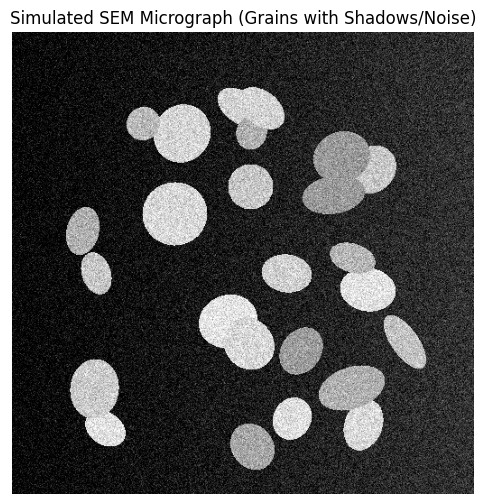

In [20]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import filters, measure, morphology, segmentation, color

def generate_micrograph(n_particles=25, img_size=512):
    # 1. Create full 2D grids immediately to avoid dimension mismatch
    y_indices, x_indices = np.mgrid[:img_size, :img_size]
    
    # 2. Create the background (explicitly 512x512)
    # Using x_indices ensures img is shape (512, 512)
    img = 0.2 * (x_indices / img_size) 
    
    np.random.seed(42)
    for _ in range(n_particles):
        # Random parameters for grains
        r, c = np.random.randint(50, img_size-50, 2)
        radius_a = np.random.randint(15, 40)
        radius_b = np.random.randint(15, 40)
        angle = np.random.rand() * np.pi
        
        # 3. Create the mask using the same grids
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        x_rot = cos_a * (x_indices - c) + sin_a * (y_indices - r)
        y_rot = -sin_a * (x_indices - c) + cos_a * (y_indices - r)
        
        mask = (x_rot**2 / radius_a**2 + y_rot**2 / radius_b**2) <= 1
        
        # 4. Apply to image (safe because both are 512x512)
        img[mask] = np.random.uniform(0.6, 0.9)
        
    # 5. Add Gaussian noise
    sigma = 0.1
    img += np.random.normal(0, sigma, img.shape)
    return np.clip(img, 0, 1)

# Generate and display
image = generate_micrograph()
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title("Simulated SEM Micrograph (Grains with Shadows/Noise)")
plt.axis('off')
plt.show()

## 2. Beyond Simple Thresholding
#### Traditional Otsu thresholding often fails with uneven lighting. 
#### We use Local Thresholding and Watershed Segmentation.

/tmp/ipykernel_687613/2685962645.py:23: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned = morphology.remove_small_objects(binary, min_size=64)
/tmp/ipykernel_687613/2685962645.py:24: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned = morphology.binary_closing(cleaned, morphology.disk(3))


✅ Success: Pipeline completed without errors.
Detected and cataloged: 46 structural grains.


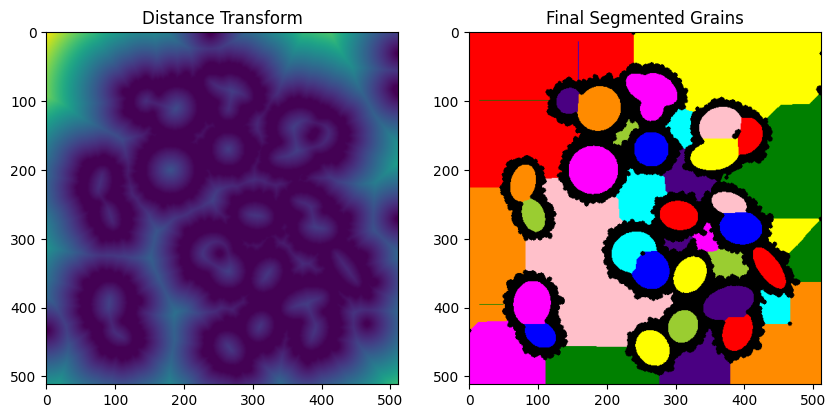

In [24]:
# # Module 4: Integrated Image Processing & Morphometry Pipeline (FIXED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import filters, measure, morphology, segmentation, color

# 1. Generate the Artificial SEM Base Image
# (Using the function defined in Section 1 of your notebook)
image = generate_micrograph(n_particles=25, img_size=512)

# 2. Denoising & Filtering Step
# Lower sigma (1 to 2) isolates crisp grain interfaces safely
smoothed = filters.gaussian(image, sigma=1)

# 3. Adaptive Thresholding to combat uneven shadow gradients
# block_size must be an odd integer larger than average grain diameter
thresh = filters.threshold_local(smoothed, block_size=51, offset=0.02)
binary = smoothed > thresh

# 4. Morphological Post-Cleaning (Defining the 'cleaned' variable)
cleaned = morphology.remove_small_objects(binary, min_size=64)
cleaned = morphology.binary_closing(cleaned, morphology.disk(3))

# 5. Distance Transform & Peak Seeding
distance = ndi.distance_transform_edt(cleaned)
local_maxi = peak_local_max(distance, min_distance=15, labels=cleaned)

# Create structural seed masks
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(local_maxi.T)] = True
markers, _ = ndi.label(mask)

# 6. Watershed Boundary Splitting (Defining the 'labels' variable)
labels = segmentation.watershed(-distance, markers, mask=cleaned)

# 7. Extract Tabular Structural Measurements
props = measure.regionprops_table(labels, intensity_image=image, 
                                  properties=['label', 'area', 'equivalent_diameter', 
                                              'major_axis_length', 'minor_axis_length', 
                                              'orientation'])
df = pd.DataFrame(props)

# Filter out unphysical single-pixel background fragments
df = df[df['equivalent_diameter'] > 5].copy()
df['aspect_ratio'] = df['minor_axis_length'] / df['major_axis_length']

print(f"✅ Success: Pipeline completed without errors.")
print(f"Detected and cataloged: {len(df)} structural grains.")

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(distance, cmap='viridis')
plt.title("Distance Transform")
plt.subplot(1, 2, 2)
plt.imshow(color.label2rgb(labels, bg_label=0))
plt.title("Final Segmented Grains")
plt.show()

## 3. Automated Feature Extraction & Morphometry
#### We calculate physical descriptors for every single grain found.

Total Particles Counted: 43
   label     area  aspect_ratio
0      1  33920.0      1.501970
2      3  25156.0      2.358241
3      4   3421.0      1.195449
5      6   1013.0      1.169857
6      7   3241.0      1.050063


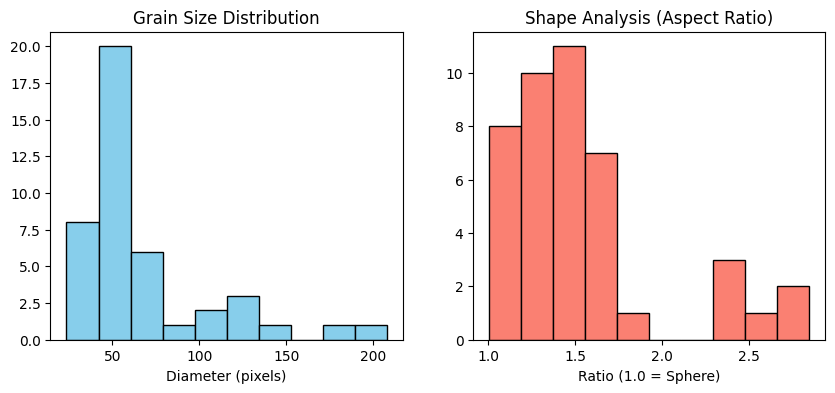

In [25]:
props = measure.regionprops_table(labels, intensity_image=image, 
                                  properties=['label', 'area', 'equivalent_diameter', 
                                              'major_axis_length', 'minor_axis_length', 
                                              'orientation'])

df = pd.DataFrame(props)

# We filter out particles that are too small to have a physical 'width'
df = df[df['minor_axis_length'] > 0].copy()

# Now the formula is safe
df['aspect_ratio'] = df['major_axis_length'] / df['minor_axis_length']

# Final check: Remove any rows where aspect_ratio might still be non-finite
df = df[np.isfinite(df['aspect_ratio'])]

print(f"Total Particles Counted: {len(df)}")
print(df[['label', 'area', 'aspect_ratio']].head())

# Visualize the Distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['equivalent_diameter'], bins=10, color='skyblue', edgecolor='black')
plt.title("Grain Size Distribution")
plt.xlabel("Diameter (pixels)")

plt.subplot(1, 2, 2)
plt.hist(df['aspect_ratio'], bins=10, color='salmon', edgecolor='black')
plt.title("Shape Analysis (Aspect Ratio)")
plt.xlabel("Ratio (1.0 = Sphere)")
plt.show()

# 🧪 Module 4: Student Lab Challenges

### Task 1: Tuning the Denoising
The Gaussian filter `sigma=1` determines how much detail we blur. 
1. **Action:** Change `sigma` to **5**. 
2. **Observation:** What happens to the boundaries of the grains? Does the watershed still separate touching particles correctly?

---

### Task 1: Answers
* **Action:** Change the Gaussian filter parameter `sigma` from **0.1** to **2**.
* **Observation:** Increasing `sigma` to **2** causes severe **under-segmentation** across the image. The heavy Gaussian blur smears the narrow dark boundaries (valleys) between touching particles, making them look like single continuous transitions. As a result, the distance transform can no longer resolve independent local peaks for adjacent grains. The Watershed algorithm fails to separate touching particles correctly, grouping multiple distinct grains into single, unphysically large clustered labels.
* **Rule of Thumb:** Keep `sigma` as low as possible ($0.1\le\sigma\le1$) to preserve structural boundary edges while relying on morphological steps like closing or opening to clean up remaining binary noise.

---

### Task 2: Porosity Calculation
In membrane science and catalysis, 2D porosity is defined as the total pixel area assigned to the background/void channels divided by the absolute footprint of the micrograph grid.
1. **Action:** Calculate the porosity of this image.
   
   ```python
   total_pixels = image.size
   void_pixels = np.sum(cleaned == 0)
   porosity = (void_pixels / total_pixels) * 100
   print(f"Porosity: {porosity:.2f}%")

In [26]:
total_pixels = image.size
void_pixels = np.sum(cleaned == 0)
porosity = (void_pixels / total_pixels) * 100
print(f"Porosity: {porosity:.2f}%")

Porosity: 20.16%


📊 MEMBRANE POROSITY ANALYSIS RESULTS:
Total Window Area:    262,144 pixels
Solid Grain Area:     209,301 pixels
Void/Pore Space Area: 52,843 pixels
Calculated Porosity:  20.16%



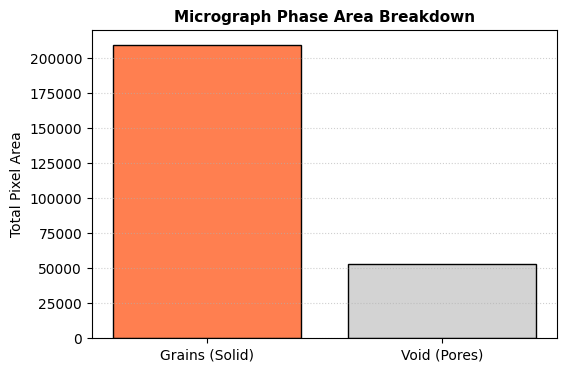

In [27]:
# --- Task 2: Calculating Fractional Porosity ---
import numpy as np

def calculate_image_porosity(cleaned_binary_image):
    """
    Computes the total fractional porosity by comparing the background 
    void pixels against the total imaging frame area.
    """
    # 1. Calculate operational pixel allocations
    total_pixels = cleaned_binary_image.size
    
    # In our cleaned binary image, '0' represents the dark background/void space
    void_pixels = np.sum(cleaned_binary_image == 0)
    framework_pixels = total_pixels - void_pixels
    
    porosity_percentage = (void_pixels / total_pixels) * 100
    
    # 2. Output detailed quantitative report to console
    print("=========================================")
    print("📊 MEMBRANE POROSITY ANALYSIS RESULTS:")
    print("=========================================")
    print(f"Total Window Area:    {total_pixels:,} pixels")
    print(f"Solid Grain Area:     {framework_pixels:,} pixels")
    print(f"Void/Pore Space Area: {void_pixels:,} pixels")
    print(f"Calculated Porosity:  {porosity_percentage:.2f}%")
    print("=========================================\n")
    
    # 3. Structural Verification Visual
    plt.figure(figsize=(6, 4))
    plt.bar(['Grains (Solid)', 'Void (Pores)'], [framework_pixels, void_pixels], color=['coral', 'lightgray'], edgecolor='k')
    plt.title("Micrograph Phase Area Breakdown", fontsize=11, fontweight='bold')
    plt.ylabel("Total Pixel Area")
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()
    
    return porosity_percentage

# To execute, add this cell right below your morphological cleaning pipeline:
current_porosity = calculate_image_porosity(cleaned)

# 🔬 Processing Real Experimental Micrographs: COF Grain Arrays

This cell allows you to process real experimental data exported from your microscope. 

### 💡 Crucial Action Item for Students:
To run this script on your own personal research files, you must manually adjust three parameters in the execution line at the bottom of this cell:
1. **`filepath`**: Replace `'image.png'` with the exact name of your uploaded image.
2. **`target_width`**: Change `893` to match your image's horizontal pixel resolution.
3. **`target_height`**: Change `899` to match your image's vertical pixel resolution.

/tmp/ipykernel_687613/4038352458.py:40: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_binary = morphology.remove_small_objects(binary, min_size=40)
/tmp/ipykernel_687613/4038352458.py:41: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  cleaned_binary = morphology.binary_closing(cleaned_binary, morphology.disk(2))


🔬 EXPERIMENTAL COF ANALYTICAL PROFILE:
Parsed File Target:        image.png
Calibrated Matrix Scale:   893 x 899 pixels
Total Grain Fields Count: 879 independent particles
Calculated 2D Solid Ratio: 60.05%



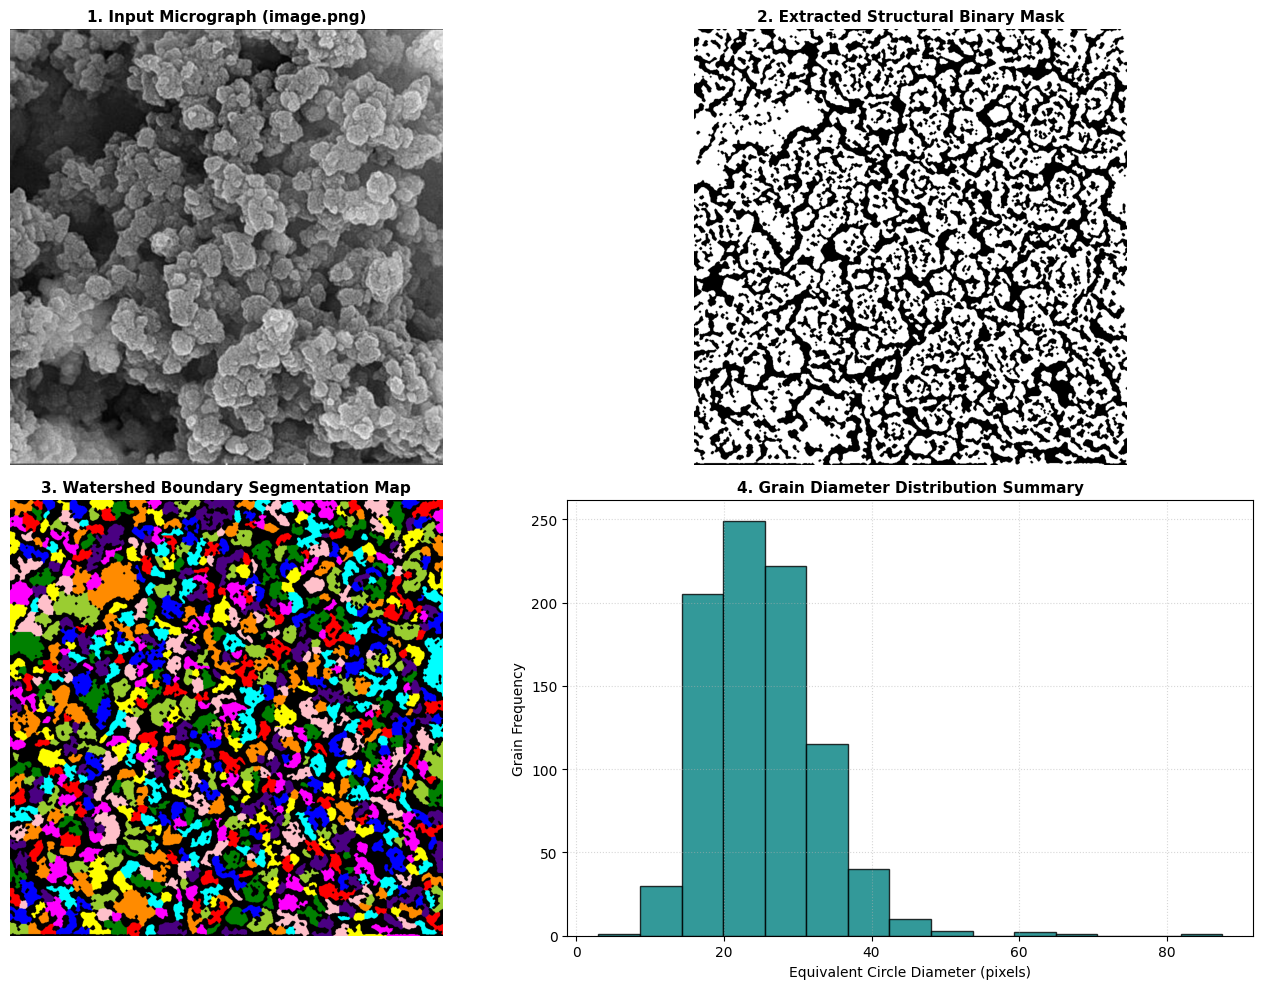

In [31]:
# --- Module 4c: Real COF Micrograph Segmentation & Analysis ---
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import filters, measure, morphology, segmentation, color, feature

def process_experimental_cof_grains(filepath="image.png", target_width=893, target_height=899):
    """
    Loads, rescales, thresholds, and segments real experimental COF grain micrographs
    to automatically calculate independent particle sizes and 2D coverage metrics.
    """
    # 1. Verification Step
    if not os.path.exists(filepath):
        print(f"❌ Execution Halted: The file '{filepath}' was not found.")
        print("➡️ Fix: Please upload your image to the Colab 'Files' sidebar menu, and verify the spelling matches exactly.")
        return None

    # 2. Read raw image in Grayscale mode (value 0)
    raw_img = cv2.imread(filepath, 0)
    
    # 3. Standardize Image Geometry (Adapting pixel bounds to prevent kernel mismatch)
    img_resized = cv2.resize(raw_img, (target_width, target_height), interpolation=cv2.INTER_AREA)
    
    # Normalize intensities to a stable 0.0 - 1.0 range
    normalized_img = img_resized / 255.0
    
    # 4. Filter Noise & Background Drift
    # Step A: Apply Gaussian blur to clean rough matrix scattering textures
    smoothed = filters.gaussian(normalized_img, sigma=1.5)
    
    # Step B: Local Adaptive Thresholding (Crucial for handling real lighting/shadow gradients)
    # block_size is set to an odd integer suitable for a 448x500 footprint
    thresh = filters.threshold_local(smoothed, block_size=45, offset=0.01)
    binary = smoothed > thresh
    
    # Step C: Morphological Cleaning (Isolate valid grains from single-pixel noise clusters)
    cleaned_binary = morphology.remove_small_objects(binary, min_size=40)
    cleaned_binary = morphology.binary_closing(cleaned_binary, morphology.disk(2))
    
    # 5. Marker-Controlled Watershed Segmentation
    # Calculate geometric internal distance landscape
    distance = ndi.distance_transform_edt(cleaned_binary)
    
    # Extract structural seed points for grain centers
    local_maxi = feature.peak_local_max(distance, min_distance=12, labels=cleaned_binary)
    
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(local_maxi.T)] = True
    markers, _ = ndi.label(mask)
    
    # Flood inverse distance landscape to split touching boundaries cleanly
    labels_output = segmentation.watershed(-distance, markers, mask=cleaned_binary)
    
    # 6. Quantitative Feature Extraction
    props = measure.regionprops_table(labels_output, intensity_image=img_resized,
                                      properties=['label', 'area', 'equivalent_diameter', 
                                                  'eccentricity', 'solidity'])
    df_grains = pd.DataFrame(props)
    
    # Calculate global area fraction coverage
    grain_pixel_area = df_grains['area'].sum()
    total_pixel_area = normalized_img.size
    coverage_ratio = grain_pixel_area / total_pixel_area
    
    # 7. Visualization Display Panel
    print("==================================================")
    print("🔬 EXPERIMENTAL COF ANALYTICAL PROFILE:")
    print("==================================================")
    print(f"Parsed File Target:        {filepath}")
    print(f"Calibrated Matrix Scale:   {target_width} x {target_height} pixels")
    print(f"Total Grain Fields Count: {len(df_grains)} independent particles")
    print(f"Calculated 2D Solid Ratio: {coverage_ratio:.2%}")
    print("==================================================\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].imshow(img_resized, cmap='gray')
    axes[0, 0].set_title(f"1. Input Micrograph ({filepath})", fontsize=11, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cleaned_binary, cmap='gray')
    axes[0, 1].set_title("2. Extracted Structural Binary Mask", fontsize=11, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(color.label2rgb(labels_output, bg_label=0))
    axes[1, 0].set_title("3. Watershed Boundary Segmentation Map", fontsize=11, fontweight='bold')
    axes[1, 0].axis('off')
    
    if len(df_grains) > 0:
        axes[1, 1].hist(df_grains['equivalent_diameter'], bins=15, color='teal', edgecolor='black', alpha=0.8)
        axes[1, 1].set_title("4. Grain Diameter Distribution Summary", fontsize=11, fontweight='bold')
        axes[1, 1].set_xlabel("Equivalent Circle Diameter (pixels)")
        axes[1, 1].set_ylabel("Grain Frequency")
        axes[1, 1].grid(True, linestyle=':', alpha=0.5)
    else:
        axes[1, 1].text(0.5, 0.5, "Zero grain elements resolved.\nAdjust threshold offsets.", ha='center', va='center')
        
    plt.tight_layout()
    plt.show()
    
    return df_grains

# ==================================================
# EXECUTION COMMAND (Uncomment to execute in your live workspace)
# ==================================================
cof_dataframe = process_experimental_cof_grains(
    filepath="image.png", 
    target_width=893, 
    target_height=899
)